In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

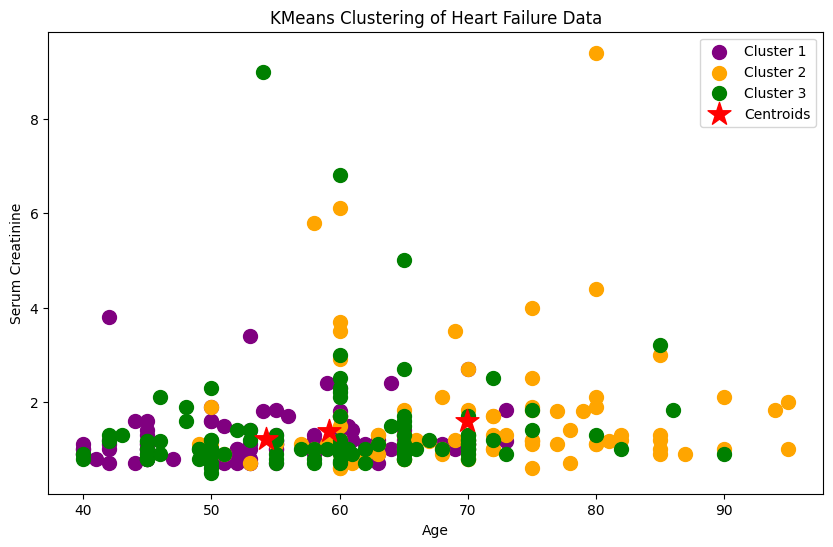

In [3]:


# Load the dataset
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

# Drop rows with missing values
df = df.dropna()

# Separate features and target
features = df.drop(columns=['DEATH_EVENT'])
target = df['DEATH_EVENT']

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply K-Means with the chosen number of clusters (e.g., 3)
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit_predict(scaled_features)

# Add the cluster labels to the dataframe
df['Cluster'] = clusters

# Plot the clusters using 'age' and 'serum_creatinine'
plt.figure(figsize=(10, 6))
plt.scatter(df[df['Cluster'] == 0]['age'], df[df['Cluster'] == 0]['serum_creatinine'], 
            s=100, c='purple', label='Cluster 1')
plt.scatter(df[df['Cluster'] == 1]['age'], df[df['Cluster'] == 1]['serum_creatinine'], 
            s=100, c='orange', label='Cluster 2')
plt.scatter(df[df['Cluster'] == 2]['age'], df[df['Cluster'] == 2]['serum_creatinine'], 
            s=100, c='green', label='Cluster 3')

# Plotting the centroids of the clusters
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, features.columns.get_loc('age')], centroids[:, features.columns.get_loc('serum_creatinine')], 
            s=300, c='red', label='Centroids', marker='*')

plt.xlabel('Age')
plt.ylabel('Serum Creatinine')
plt.legend() 
plt.title('KMeans Clustering of Heart Failure Data')
plt.show()
